# PyMOL renders of canonically-oriented TCR-pMHC complexes

Publication-style ray-traced PyMOL panels of the **Canonical2026** set (HF
`isalgo/tcren_structures`, oriented by `tcren orient`). Three view families, each over the
four MHC class × species groups (human/mouse × MHCI/MHCII):

1. **Overlay + axes** — all structures of a group superposed in canonical coordinates, with
   black x/y/z axes. Camera looks down **x** (the thin axis) so the **y–z** plane (peptide ×
   MHC→TCR) is the image; a roll places +y ~120° / −y ~60° from screen-up.
2. **Top-down groove** — looking down **z** onto the peptide (sticks) in the MHC groove
   (ribbon), groove coloured by domain (α-helices vs β-sheet floor).
3. **Interface** — x toward viewer (y–z plane), peptide + CDR1–3 α/β loops (ribbon + sticks)
   over the MHC ribbon.

Rendering drives the headless PyMOL binary; structures load straight from the gzipped
Canonical2026 mmCIF/PDB. Chain roles after orientation: A=Vα, B=Vβ, C=peptide, D=MHCα,
E=MHCβ/β2m.

In [1]:
# Setup: group oriented structures + a headless-PyMOL render helper.
import json, subprocess, shutil, tempfile, collections
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.image as mpimg

CANON = Path('../data/Canonical2026')   # repo-root data/ (notebook cwd is notebooks/)
PYMOL = shutil.which('pymol') or '/opt/homebrew/bin/pymol'
GROUPS = [('MHCI', 'Human'), ('MHCII', 'Human'), ('MHCI', 'Mouse'), ('MHCII', 'Mouse')]

meta = [r for r in json.load(open('../data/orient_metadata.json')) if r.get('status') == 'ok']
by_group = collections.defaultdict(list)
for r in meta:
    if (CANON / f"{r['pdb.id']}.pdb.gz").exists():
        by_group[(r['mhc.class'], r['species'])].append(r['pdb.id'])
print({g: len(by_group[g]) for g in GROUPS})

_AXES = "\n".join([
    "from pymol.cgo import CYLINDER",
    "L=42.0; r=0.7",
    "cmd.load_cgo([CYLINDER,0,0,0,L,0,0,r,0,0,0,0,0,0, CYLINDER,0,0,0,0,L,0,r,0,0,0,0,0,0,",
    "              CYLINDER,0,0,0,0,0,L,r,0,0,0,0,0,0],'axes')",
])

_HEADER = "\n".join([
    "from pymol import cmd",
    "cmd.bg_color('white'); cmd.set('ray_opaque_background',0); cmd.set('orthoscopic',1)",
    "cmd.set('cartoon_transparency',0.0); cmd.set('ray_shadows',0)",
])

def pymol_png(body, png, size=700):
    # Run a PyMOL python-script body headless and write a ray-traced PNG.
    script = _HEADER + "\n" + body + "\ncmd.ray(%d,%d); cmd.png(r'%s', dpi=120)\n" % (size, size, png)
    with tempfile.NamedTemporaryFile('w', suffix='.py', delete=False) as fh:
        fh.write(script); path = fh.name
    subprocess.run([PYMOL, '-cq', path], check=True, capture_output=True)
    return png

def panel(pngs, titles, suptitle):
    fig, ax = plt.subplots(2, 2, figsize=(11, 11))
    for a, p, t in zip(ax.ravel(), pngs, titles):
        a.imshow(mpimg.imread(p)); a.set_title(t, fontsize=12); a.axis('off')
    fig.suptitle(suptitle, fontsize=15); plt.tight_layout(); plt.show()

{('MHCI', 'Human'): 228, ('MHCII', 'Human'): 55, ('MHCI', 'Mouse'): 52, ('MHCII', 'Mouse'): 39}


## 1. Overlay in canonical coordinates with x/y/z axes (y–z plane, x toward viewer)

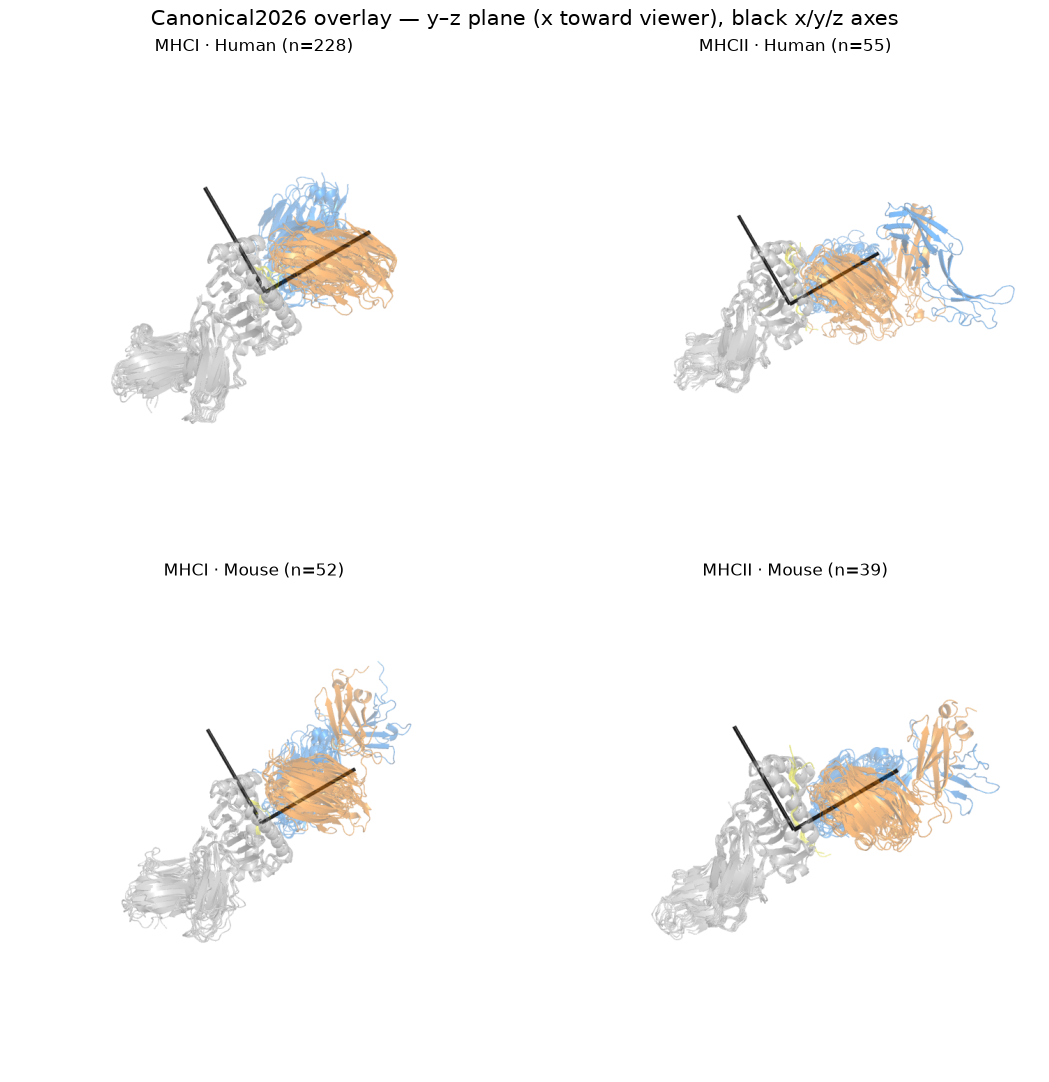

In [2]:
# Up to 8 structures per group overlaid; black axes; look down x with a ~120/60 roll about x.
def view_overlay(ids, png):
    loads = '\n'.join(f'cmd.load(r"{CANON}/{p}.pdb.gz", "{p}")' for p in ids)
    body = f'''{loads}
cmd.hide("everything"); cmd.show("cartoon"); cmd.set("cartoon_transparency",0.5)
cmd.color("marine","chain A"); cmd.color("orange","chain B")
cmd.color("yellow","chain C"); cmd.color("grey70","chain D+E")
{_AXES}
cmd.set_view([0.,1.,0., 0.,0.,1., 1.,0.,0., 0.,0.,-300., 0.,0.,0., 100.,520.,0.])
cmd.turn("z", 30)   # roll about the viewing (x) axis: +y -> ~120 deg from screen-up
cmd.zoom("all", buffer=8, complete=1)'''
    return pymol_png(body, png)

pngs = [view_overlay(by_group[g][:8], Path(f'/tmp/ov_{g[0]}_{g[1]}.png')) for g in GROUPS]
panel(pngs, [f'{c} · {s} (n={len(by_group[(c,s)])})' for c, s in GROUPS],
      'Canonical2026 overlay — y–z plane (x toward viewer), black x/y/z axes')

## 2. Top-down (z→bottom): peptide sticks in the MHC groove, groove coloured by domain

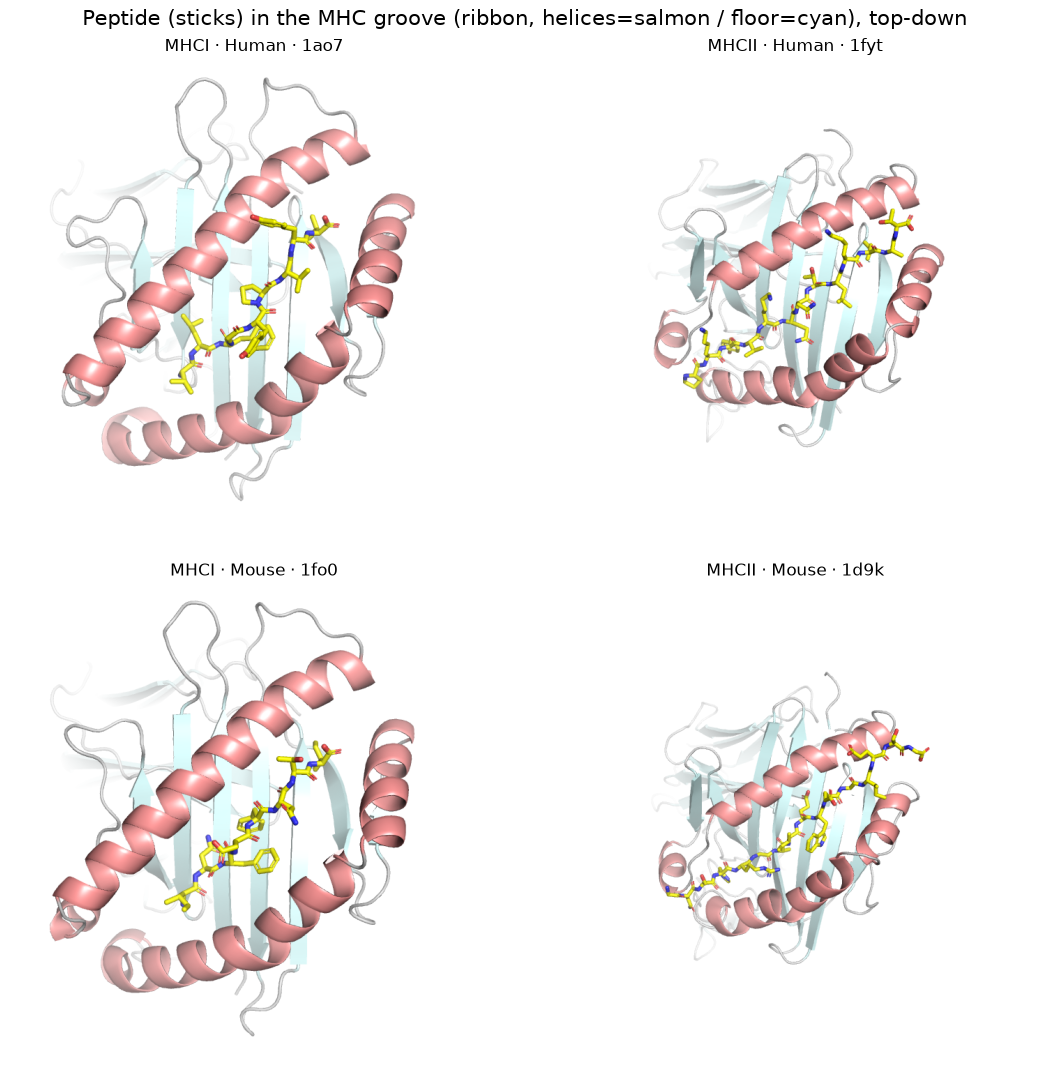

In [3]:
# One representative per group; look down z; MHC ribbon coloured by domain (helices vs floor).
def view_groove(pid, png):
    body = f'''cmd.load(r"{CANON}/{pid}.pdb.gz", "m")
cmd.hide("everything")
cmd.show("cartoon", "chain D+E"); cmd.set("cartoon_transparency",0.0)
cmd.color("grey80", "chain D+E")
cmd.color("salmon", "chain D+E and ss H")     # groove alpha-helices (HELIX_A1/A2 or A1/B1)
cmd.color("palecyan", "chain D+E and ss S")   # groove beta-sheet floor
cmd.show("sticks", "chain C"); cmd.color("yellow", "chain C"); cmd.set("stick_radius",0.3)
cmd.util.cnc("chain C")
# look down z (z toward viewer from the top): screen out=+z, up=+y, right=+x
cmd.set_view([1.,0.,0., 0.,1.,0., 0.,0.,1., 0.,0.,-250., 0.,0.,0., 100.,420.,0.])
cmd.zoom("chain C", buffer=14, complete=1)'''
    return pymol_png(body, png)

pngs = [view_groove(by_group[g][0], Path(f'/tmp/gr_{g[0]}_{g[1]}.png')) for g in GROUPS]
panel(pngs, [f'{c} · {s} · {by_group[(c,s)][0]}' for c, s in GROUPS],
      'Peptide (sticks) in the MHC groove (ribbon, helices=salmon / floor=cyan), top-down')

## 3. Interface: peptide + CDR1–3 α/β loops over the MHC (x toward viewer)

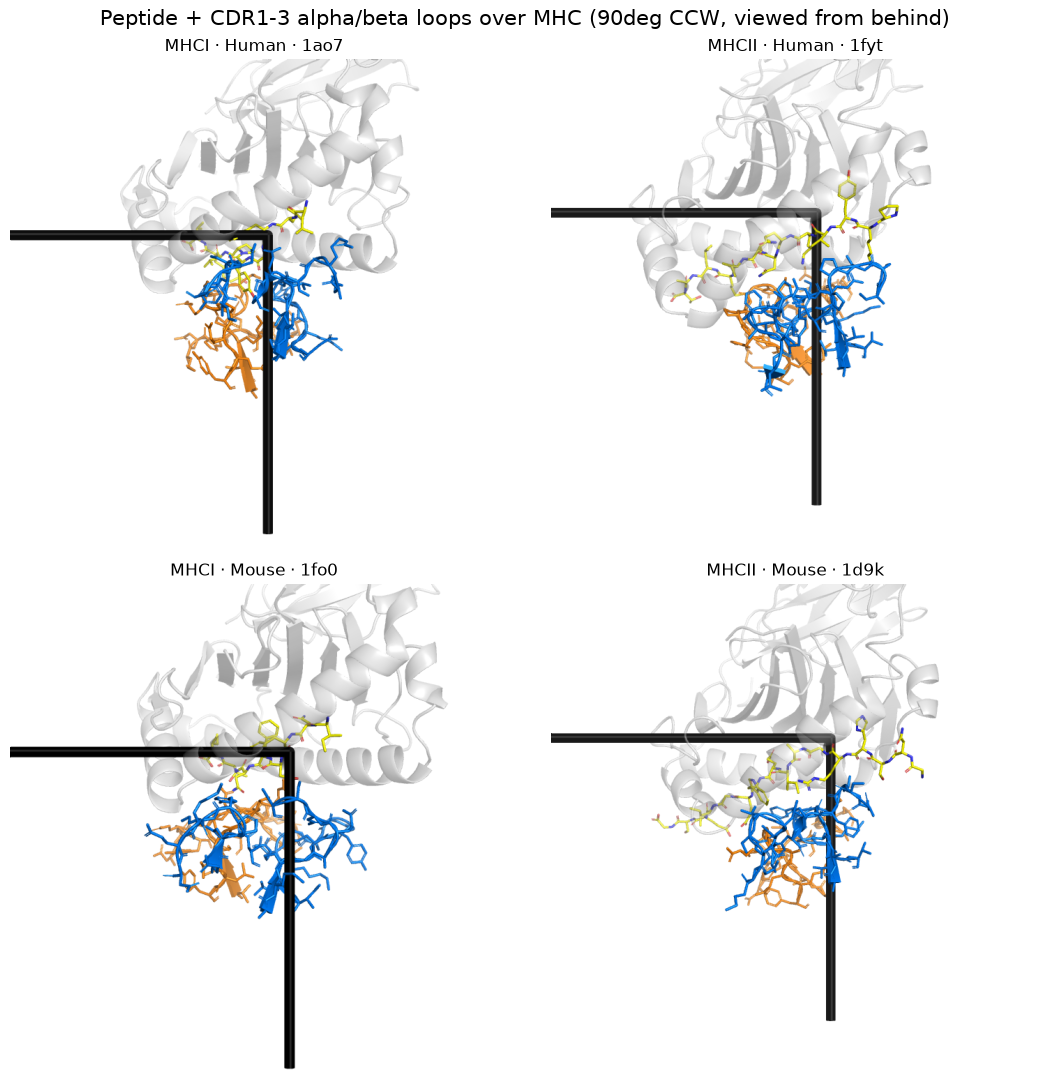

In [4]:
# CDR resi come from annotating the (pre-orient) Native2026 structure; pdb numbering is preserved
# through orientation, so they select chain A/B (=TRA/TRB) in the oriented file.
import warnings; warnings.filterwarnings('ignore')
from tcren.structure import import_structure
from tcren.annotation import classify_chains

def cdr_resi(pid):
    s = import_structure(f'../data/Native2026/{pid}.pdb.gz', pdb_id=pid)
    classify_chains(s, organism='human')
    out = {'TRA': [], 'TRB': []}
    for c in s.chains:
        if c.chain_type in out:
            for reg in c.regions:
                if reg.region_type.startswith('CDR'):
                    out[c.chain_type] += [r.pdb_index for r in reg.residues]
    return out

def view_interface(pid, png):
    cdr = cdr_resi(pid)
    ra = '+'.join(map(str, cdr['TRA'])) or '0'; rb = '+'.join(map(str, cdr['TRB'])) or '0'
    body = f'''cmd.load(r"{CANON}/{pid}.pdb.gz", "m")
cmd.hide("everything")
cmd.show("cartoon", "chain D+E"); cmd.color("grey80","chain D+E"); cmd.set("cartoon_transparency",0.55,"chain D+E")
cmd.show("sticks","chain C"); cmd.color("yellow","chain C"); cmd.util.cnc("chain C")
cmd.show("cartoon","chain A and resi {ra}"); cmd.color("marine","chain A and resi {ra}")
cmd.show("cartoon","chain B and resi {rb}"); cmd.color("orange","chain B and resi {rb}")
cmd.show("sticks","(chain A and resi {ra}) or (chain B and resi {rb})"); cmd.set("stick_radius",0.18)
{_AXES}
cmd.set_view([0.,1.,0., 0.,0.,1., 1.,0.,0., 0.,0.,-220., 0.,0.,0., 60.,400.,0.])
cmd.turn("y", 180)   # mirror: look from behind
cmd.turn("z", 90)    # 90 deg counterclockwise
cmd.zoom("chain C or (chain A and resi {ra}) or (chain B and resi {rb})", buffer=10, complete=1)'''
    return pymol_png(body, png)

pngs = [view_interface(by_group[g][0], Path(f'/tmp/if_{g[0]}_{g[1]}.png')) for g in GROUPS]
panel(pngs, [f'{c} · {s} · {by_group[(c,s)][0]}' for c, s in GROUPS],
      'Peptide + CDR1-3 alpha/beta loops over MHC (90deg CCW, viewed from behind)')

## 4. histo.fyi-style pocket view (e.g. [5tez](https://www.histo.fyi/structures/view/5tez))

The histo.fyi layout: a clean top-down look into the peptide-binding groove — MHC as a pale
surface/ribbon, the peptide as coloured sticks threaded along the cleft, on a white background.

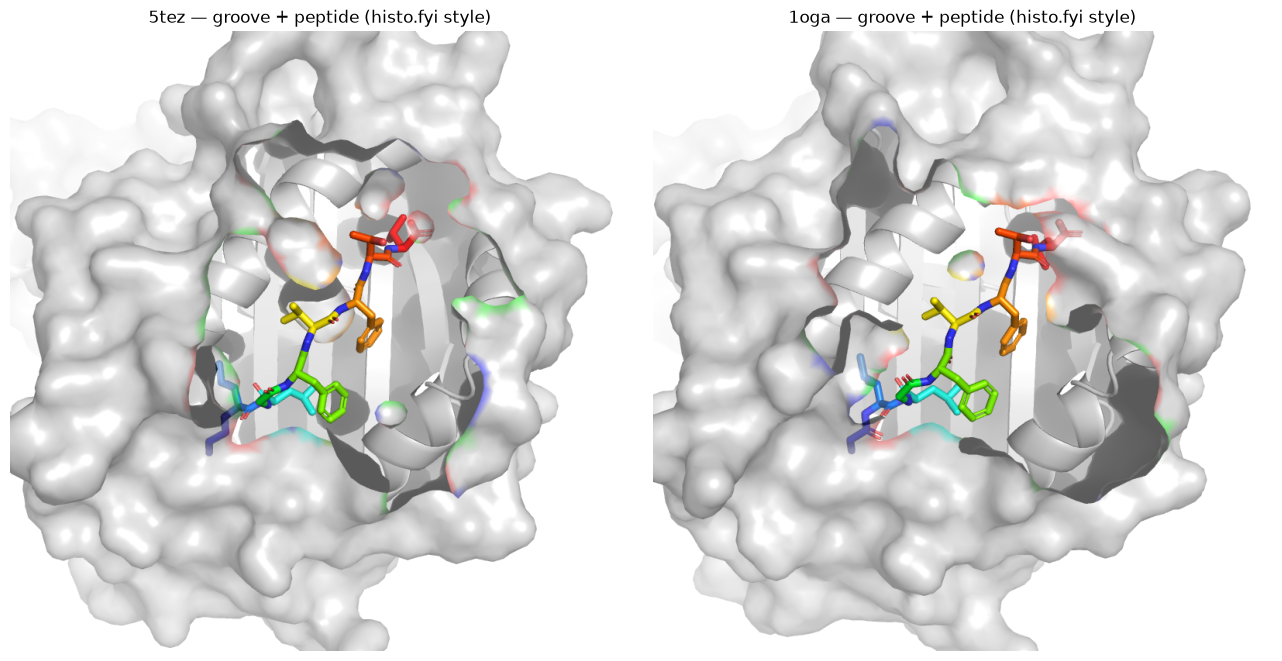

In [5]:
# histo.fyi-style groove close-ups for a couple of complexes.
def view_histofyi(pid, png):
    body = f'''cmd.load(r"{CANON}/{pid}.pdb.gz", "m")
cmd.hide("everything")
cmd.show("surface", "chain D+E"); cmd.set("transparency", 0.35); cmd.color("grey80", "chain D+E")
cmd.show("cartoon", "chain D+E"); cmd.set("cartoon_transparency", 0.2, "chain D+E")
cmd.show("sticks", "chain C"); cmd.spectrum("resi", "rainbow", "chain C"); cmd.util.cnc("chain C")
cmd.set("stick_radius", 0.3)
cmd.set_view([1.,0.,0., 0.,1.,0., 0.,0.,1., 0.,0.,-200., 0.,0.,0., 100.,360.,0.])
cmd.zoom("chain C", buffer=10, complete=1)'''
    return pymol_png(body, png, size=800)

avail = lambda p: (CANON / f'{p}.pdb.gz').exists()
ex = [p for p in ('5tez', '1oga') if avail(p)] or [by_group[('MHCI', 'Human')][0]]
pngs = [view_histofyi(p, Path(f'/tmp/hf_{p}.png')) for p in ex]
fig, ax = plt.subplots(1, len(pngs), figsize=(6.5 * len(pngs), 6.5), squeeze=False)
for a, p, pid in zip(ax.ravel(), pngs, ex):
    a.imshow(mpimg.imread(p)); a.set_title(f'{pid} — groove + peptide (histo.fyi style)'); a.axis('off')
plt.tight_layout(); plt.show()